📂 Please upload your FASTA file (sequence.fasta or clean_sequence.fasta)


Saving clean_sequence.fasta to clean_sequence (1).fasta
✅ File uploaded: clean_sequence (1).fasta
✅ FASTA file loaded & cleaned
Total sequences: 1
Length of first sequence: 23453864
✅ Cleaned sequence saved as clean_sequence.fasta
✅ Extracted 23453862 3-mers
✅ K-mer frequencies saved as kmer_frequencies.csv
✅ Loaded k-mer frequencies
  kmer    count
0  AAA  1023672
1  TTT  1009756
2  AAT   690822
3  ATT   688037
4  ATA   590926

🔍 Top 10 K-mers:
  kmer    count
0  AAA  1023672
1  TTT  1009756
2  AAT   690822
3  ATT   688037
4  ATA   590926
5  TAT   588138
6  TAA   585703
7  TTA   582519
8  CAA   555354
9  TTG   552866


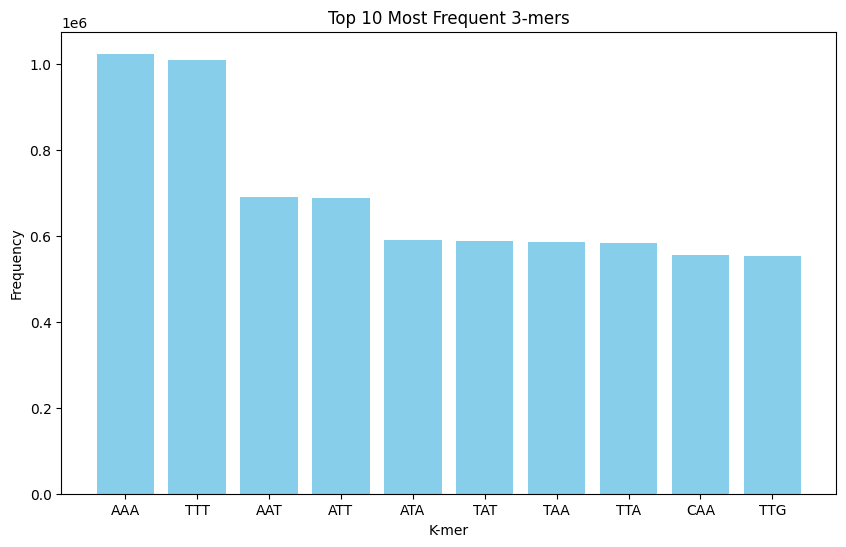


🧪 Base Composition (%): {'A': 31.91268457194811, 'T': 31.756215671431853, 'C': 18.156203869537563, 'G': 18.17484898649101, 'R': 1.7054760533680978e-05, 'W': 8.527380266840489e-06, 'Y': 8.527380266840489e-06, 'S': 4.263690133420244e-06, 'M': 8.527380266840489e-06}


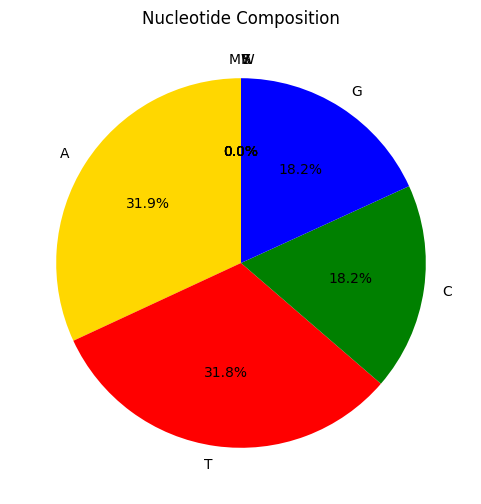

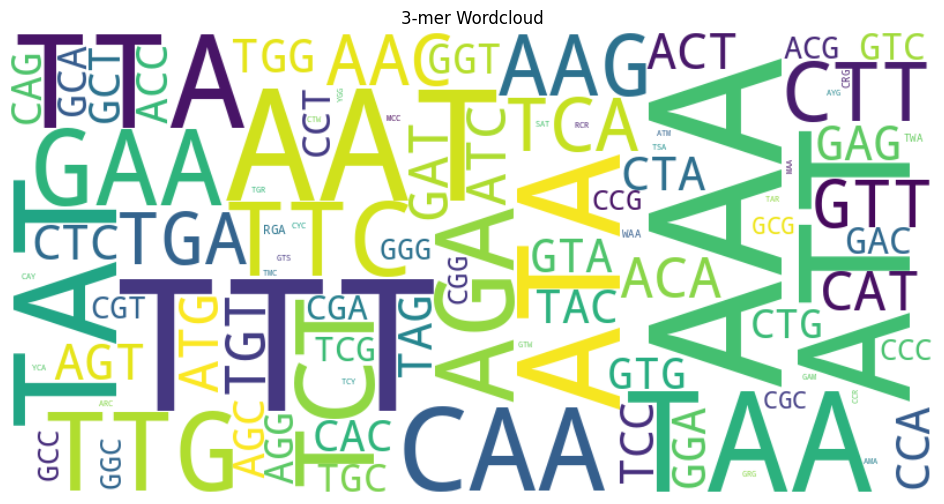

In [2]:
# ========================
# Step 0: Upload FASTA File
# ========================
from google.colab import files

print("📂 Please upload your FASTA file (sequence.fasta or clean_sequence.fasta)")
uploaded = files.upload()

# Change filename if needed
file_path = list(uploaded.keys())[0]
print("✅ File uploaded:", file_path)

# ========================
# Step 1: Preprocessing
# ========================
from collections import Counter
import csv

clean_fasta = "clean_sequence.fasta"
kmer_csv = "kmer_frequencies.csv"
k = 3   # you can change this (3=codons, 4/5 for language-style)

# Read & Clean FASTA
sequences = []
seq_lines = []

with open(file_path, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            if seq_lines:
                sequences.append("".join(seq_lines).upper().replace("N", ""))
                seq_lines = []
        else:
            seq_lines.append(line)
    if seq_lines:
        sequences.append("".join(seq_lines).upper().replace("N", ""))

print("✅ FASTA file loaded & cleaned")
print("Total sequences:", len(sequences))
print("Length of first sequence:", len(sequences[0]))

# Save cleaned sequence
with open(clean_fasta, "w") as f:
    for i, seq in enumerate(sequences):
        f.write(f">clean_sequence_{i+1}\n")
        for j in range(0, len(seq), 70):
            f.write(seq[j:j+70] + "\n")

print(f"✅ Cleaned sequence saved as {clean_fasta}")

# Generate k-mers
def get_kmers(seq, k):
    return [seq[i:i+k] for i in range(len(seq)-k+1)]

all_kmers = []
for seq in sequences:
    all_kmers.extend(get_kmers(seq, k))

print(f"✅ Extracted {len(all_kmers)} {k}-mers")

# Count k-mer frequencies
kmer_counts = Counter(all_kmers)

# Save to CSV
with open(kmer_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["kmer", "count"])
    for kmer, count in kmer_counts.most_common():
        writer.writerow([kmer, count])

print(f"✅ K-mer frequencies saved as {kmer_csv}")

# ========================
# Step 2: Analysis & Plots
# ========================
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load CSV
df = pd.read_csv(kmer_csv)
print("✅ Loaded k-mer frequencies")
print(df.head())

# Top 10 K-mers
top10 = df.head(10)
print("\n🔍 Top 10 K-mers:")
print(top10)

# Bar Chart
plt.figure(figsize=(10,6))
plt.bar(top10['kmer'], top10['count'], color='skyblue')
plt.xlabel("K-mer")
plt.ylabel("Frequency")
plt.title(f"Top 10 Most Frequent {k}-mers")
plt.show()

# Base Composition
from collections import Counter
base_counts = Counter()
for kmer, count in zip(df['kmer'], df['count']):
    for base in kmer:
        base_counts[base] += count

total_bases = sum(base_counts.values())
base_percent = {b: (c/total_bases)*100 for b, c in base_counts.items()}
print("\n🧪 Base Composition (%):", base_percent)

# Pie Chart
plt.figure(figsize=(6,6))
plt.pie(base_percent.values(), labels=base_percent.keys(), autopct='%1.1f%%',
        startangle=90, colors=['gold','red','green','blue'])
plt.title("Nucleotide Composition")
plt.show()

# Wordcloud (Optional)
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(dict(zip(df['kmer'], df['count'])))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"{k}-mer Wordcloud")
plt.show()
